In [1]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np

from dotenv import load_dotenv
load_dotenv()
# DATASET_PATH=os.getenv("DATASET_DIRECTORY")
DATASET_PATH="/data/Hermes"
CONFIG_DIRECTORY = os.getenv("CONFIG_DIRECTORY")

sys.path.append("../")
from mmwave_radar_processing.config_managers.cfgManager import ConfigManager
from cpsl_datasets.cpsl_ds import CpslDS
from mmwave_radar_processing.processors.range_angle_resp import RangeAngleProcessor
from mmwave_radar_processing.processors.range_doppler_resp import RangeDopplerProcessor
from mmwave_radar_processing.processors.doppler_azimuth_resp import DopplerAzimuthProcessor
from mmwave_radar_processing.processors.range_angle_resp_dbs_enhanced import RangeAngleProcessorDBSEnhanced
from mmwave_radar_processing.processors.micro_doppler_resp import MicroDopplerProcessor
from mmwave_radar_processing.processors.virtual_array_reformater import VirtualArrayReformatter
from mmwave_radar_processing.plotting.plotter_mmWave_data import PlotterMmWaveData
from mmwave_radar_processing.plotting.movies_mmWave_data import MovieGeneratorMmWaveData


/home/david/.cache/pypoetry/virtualenvs/mmwave-radar-processing-ERvCMkmn-py3.12/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
cfg_manager = ConfigManager()

cfg_path = os.path.join(CONFIG_DIRECTORY,"1843_RadVel_10Hz_lr.cfg")
cfg_manager.load_cfg(cfg_path,array_geometry="standard",array_direction="out")
cfg_manager.compute_radar_perforance(profile_idx=0)
cfg_manager.print_cfg_overview()

---- Radar Configuration Overview ----
Radar Performance
	range res: 0.14m
	range max: 12.29m
	vel res: 0.02m/s
	vel max: 1.22m/s
Profile Configuration:
	profile config: 
	{'profileId': 0, 'startFreq_GHz': 77.0, 'idleTime_us': 300.0, 'adcStartTime_us': 7.0, 'rampEndTime_us': 100.0, 'txOutPower': 0.0, 'txPhaseShifter': 0.0, 'freqSlope_MHz_us': 25.0, 'txStartTime_us': 1.0, 'adcSamples': 90, 'sampleRate_kSps': 2050, 'hpfCornerFreq1': 0, 'hpfCornerFreq2': 0, 'rxGain_dB': 30.0}
	Frame loops: 100
	Chirp period: 400.0 us
	Active frame time: 80.0 ms
	Frame period: 100.0
	Antenna Geometry: standard
	Operating Frequency: 77.0 GHz


In [3]:
#load the dataset
dataset_name = "hermes_hudson_driveway"
dataset_path = os.path.join(DATASET_PATH,dataset_name)
print(dataset_path)
# dataset_name = "RadSAR_2_CPSL"
# dataset_path = os.path.join(DATASET_PATH,os.pardir,"RadSAR",dataset_name)
dataset = CpslDS(
    dataset_path=dataset_path,
    radar_adc_folder="front_radar_adc", #or "front_radar"
    lidar_folder="lidar",
    camera_folder="camera",
    hand_tracking_folder="hand_tracking",
    imu_orientation_folder="imu_orientation", #not implemented
    imu_full_folder="imu_data",
    vehicle_vel_folder="vehicle_vel",
    vehicle_odom_folder="vehicle_odom"
)

/data/Hermes/hermes_hudson_driveway
found 739 radar ADC samples
found 739 lidar samples
did not find camera samples
did not find hand tracking samples
did not find imu (orientation) samples
did not find imu (full data) samples
found 739 vehicle velocity samples
found 739 vehicle odometry samples


In [4]:
#load the plotter
plotter = PlotterMmWaveData(config_manager=cfg_manager)

#initialize the range doppler processor
range_doppler_processor = RangeDopplerProcessor(
    config_manager=cfg_manager
)

#initialize the range doppler processor
if dataset.vehicle_odom_enabled:
    range_az_processor = RangeAngleProcessorDBSEnhanced(
        config_manager=cfg_manager,
        num_angle_bins_range_angle_response=64,
        num_angle_bins_dbs_enhanced_response=100,
        min_x_y_vel_dbs=0.25,
    )
else:
    range_az_processor = RangeAngleProcessor(
        config_manager=cfg_manager,
        num_angle_bins=64
    )

doppler_azimuth_processor = DopplerAzimuthProcessor(
    config_manager=cfg_manager,
    num_angle_bins=64
)

micro_doppler_processor = MicroDopplerProcessor(
    config_manager=cfg_manager,
    target_ranges=np.array([3.0,3.7]),
    num_frames_history=20
)

#load the ADC data reformatter
virtual_array_reformatter = VirtualArrayReformatter(config_manager=cfg_manager)

#initialize the movie generator
movie_generator = MovieGeneratorMmWaveData(
    cpsl_dataset=dataset,
    plotter=plotter,
    range_azimuth_processor=range_az_processor,
    range_doppler_processor=range_doppler_processor,
    doppler_azimuth_processor=doppler_azimuth_processor,
    micro_doppler_processor=micro_doppler_processor,
    virtual_array_reformatter=virtual_array_reformatter,
    temp_dir_path=os.path.join("~/Downloads/Hermes",dataset_name)
)

found temp dir: /home/david/Downloads/Hermes/hermes_hudson_driveway
clearing temp directory /home/david/Downloads/Hermes/hermes_hudson_driveway


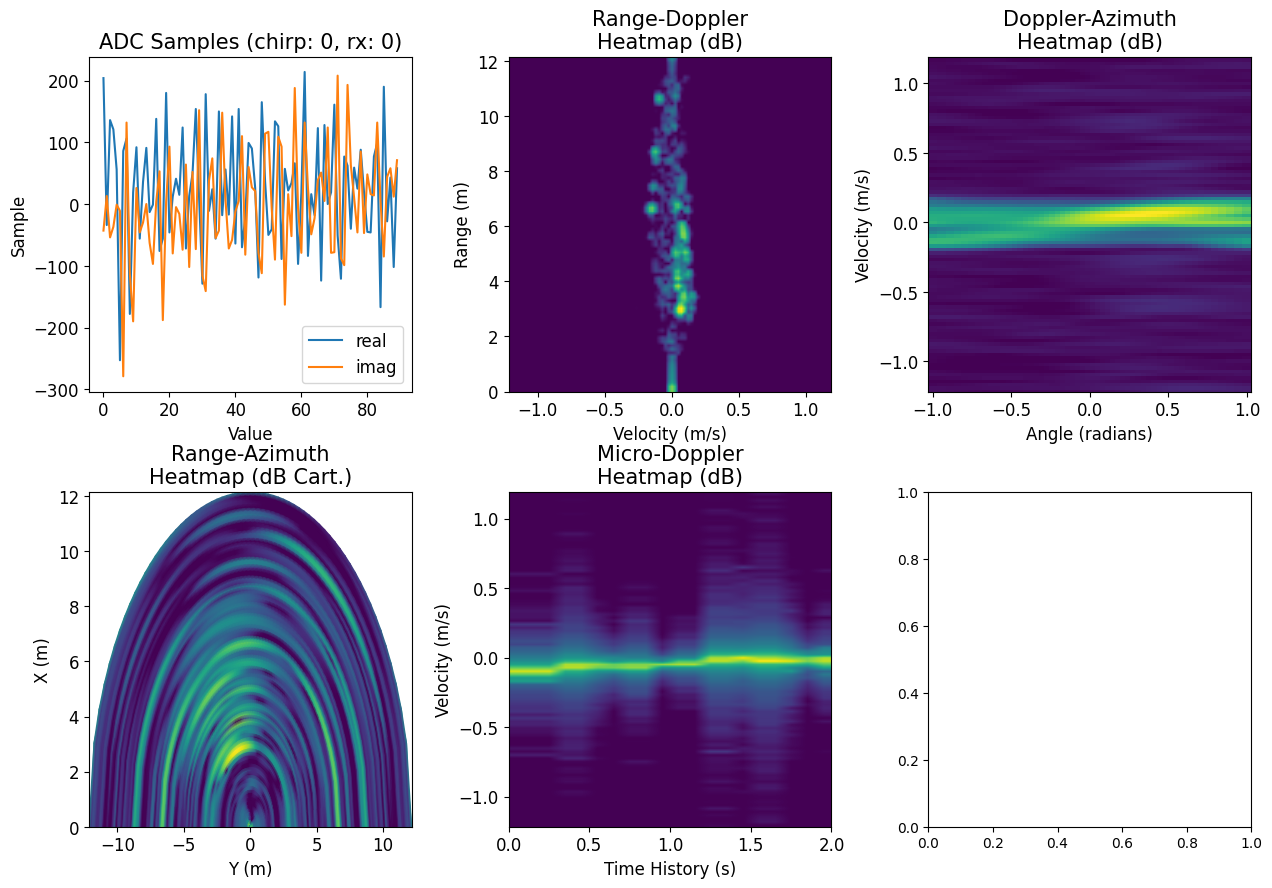

In [5]:
#for getting access to the adc cube
idx=158 - micro_doppler_processor.num_frames_history
#compute responses over a series of frames
for i in range(micro_doppler_processor.num_frames_history):

    #get the ADC cube
    adc_cube = dataset.get_radar_adc_data(idx + i)

    if dataset.vehicle_odom_enabled:
        vel_data = np.mean(dataset.get_vehicle_odom_data(idx)[:,8:11],axis=0)
        #convert into ned
        ned_vel_data = np.array([
            vel_data[0],
            vel_data[1],
            vel_data[2]
        ])
    else:
        ned_vel_data = np.zeros(shape=(1,3))
    adc_cube = virtual_array_reformatter.process(adc_cube)
    rng_az_resp = range_az_processor.process(
        adc_cube=adc_cube,
        velocity_ned=ned_vel_data)
    rng_dop_resp = range_doppler_processor.process(adc_cube=adc_cube,rx_idx=0)
    dop_az_resp = doppler_azimuth_processor.process(adc_cube=adc_cube)
    micro_doppler_resp = micro_doppler_processor.process(adc_cube=adc_cube,rx_idx=0)

    try:
        camera_view = dataset.get_camera_frame(idx + i)
    except AssertionError:
        camera_view = np.empty(shape=(0))

#for generating a compilation of plots
fig,axs=plt.subplots(2,3, figsize=(15,10))
fig.subplots_adjust(wspace=0.3,hspace=0.30)

plotter.plot_compilation(
    adc_cube=adc_cube,
    velocity_ned=ned_vel_data,
    range_doppler_processor=range_doppler_processor,
    range_azimuth_processor=range_az_processor,
    doppler_azimuth_processor=doppler_azimuth_processor,
    micro_doppler_processor=micro_doppler_processor,
    camera_view=camera_view,
    convert_to_dB=True,
    cmap="viridis",
    chirp_idx=0,
    rx_antenna_idx=0,
    axs=axs,
    show=True
)

  0%|          | 0/739 [00:00<?, ?it/s]/home/david/Documents/mmwave_radar_processing/mmwave_radar_processing/plotting/plotter_mmWave_data.py:288: RuntimeWarning: divide by zero encountered in log10
  resp = 20 * np.log10(resp)
  0%|          | 3/739 [00:01<04:55,  2.49it/s]

100%|██████████| 739/739 [00:49<00:00, 15.06it/s]


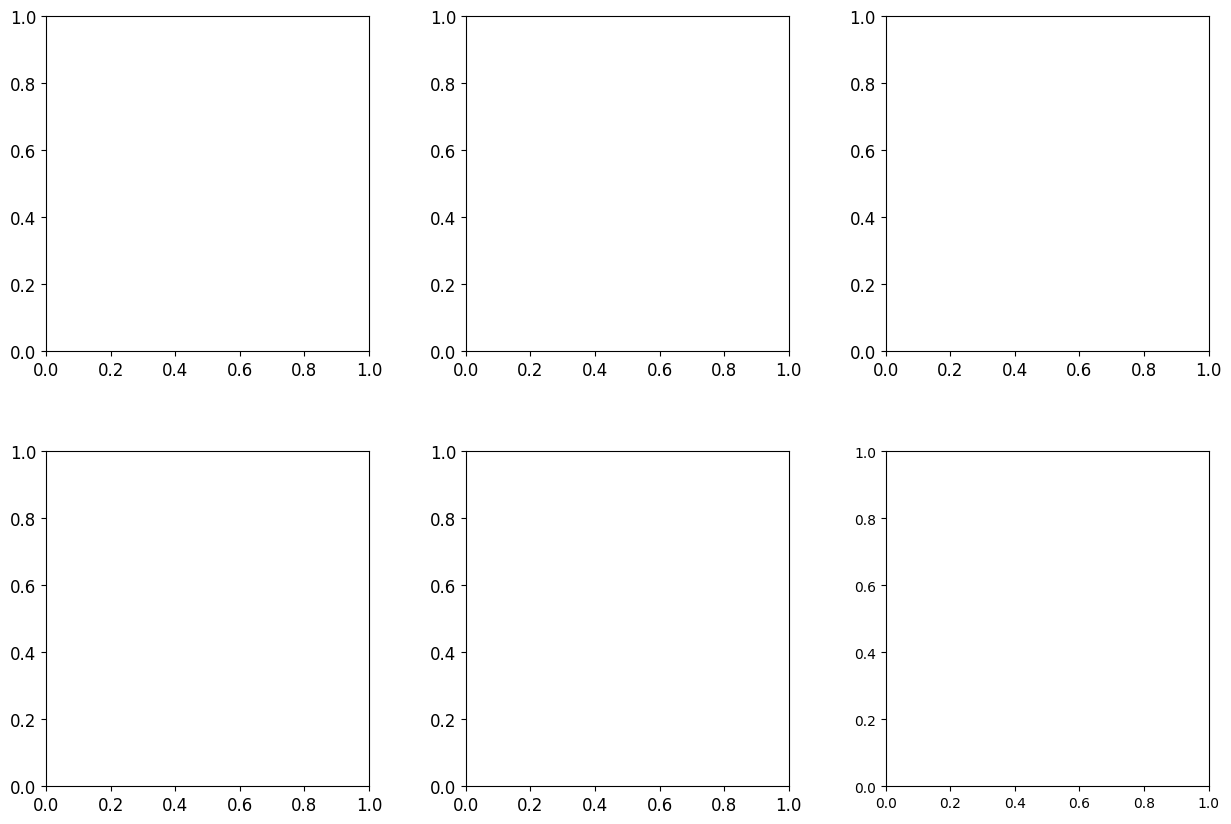

In [6]:
#generate the movie - initialize the figure
movie_generator.initialize_figure(nrows=2,ncols=3,figsize=(15,10))

#reset the microdoppler signature
movie_generator.micro_doppler_processor.micro_doppler_resp = np.zeros_like(movie_generator.micro_doppler_processor.micro_doppler_resp)

#generate the movie frames
movie_generator.generate_movie_frames(
    chirp_idx=0,
    rx_antenna_idx=0,
    cmap="viridis",
    convert_to_dB=True
)

fps = 1 / (1e-3 * cfg_manager.frameCfg_periodicity_ms)
movie_generator.save_movie(video_file_name="{}_raw.mp4".format(dataset_name),fps=fps)

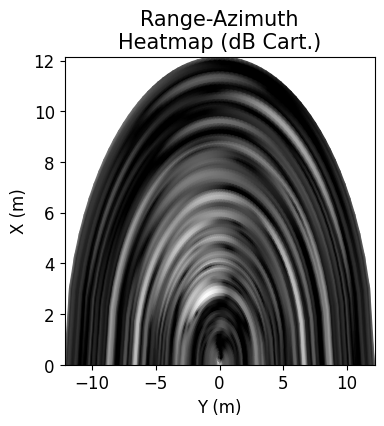

In [7]:
fig,ax = plt.subplots(figsize=(4,4))

plotter.plot_range_az_resp_cart(
    resp=rng_az_resp,
    range_azimuth_processor=range_az_processor,
    convert_to_dB=True,
    cmap="grey",
    ax=ax,
    show=False
)
